In [1]:
pip install albumentations opencv-python

Note: you may need to restart the kernel to use updated packages.


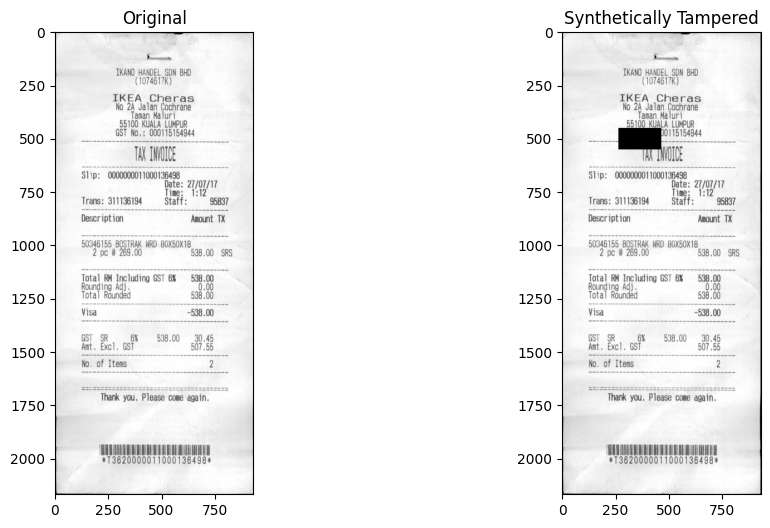

In [2]:
import sys
sys.path.append('..')
from src.augmentation import create_synthetic_tamper
import matplotlib.pyplot as plt
import cv2
import os

input_img = "../data/train/X51005568913.png" 
output_img = "../data/train/synthetic_forged_3.png"

if os.path.exists(input_img):
    create_synthetic_tamper(input_img, output_img)

    original = cv2.imread(input_img)
    forged = cv2.imread(output_img)
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original")
    ax[1].imshow(cv2.cvtColor(forged, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Synthetically Tampered")
    plt.show()
else:
    print(f"File {input_img} not found. Please check your data/train folder for a valid filename.")

In [3]:
import json
import os
import sys
sys.path.append('..')
from src.augmentation import create_synthetic_tamper

training_data = []
train_dir = os.path.abspath("../data/train")

extensions = ('.png')
train_files = [f for f in os.listdir(train_dir) 
               if f.lower().endswith(extensions) 
               and not f.startswith('synth_') 
               and not f.startswith('synthetic_')]

print(f"Found {len(train_files)} clean base images.")

if len(train_files) == 0:
    print("Check your folder! Are the images named 'synthetic_...'? If so, they are being skipped.")
else:
    for filename in train_files:
        img_path = os.path.join(train_dir, filename)
        out_name = f"synth_{filename}"
        out_path = os.path.join(train_dir, out_name)

        print(f"Processing: {filename}...", end=" ")
        
        boxes = create_synthetic_tamper(img_path, out_path)
        
        if boxes:
            training_data.append({
                "filename": out_name,
                "bbox": boxes[0], 
                "label": "tampered_region"
            })
            print("Success!")
        else:
            print("Failed (Check if file is corrupted).")

    metadata_path = os.path.join(train_dir, "synthetic_metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(training_data, f, indent=4)

    print(f"\n--- Final Results ---")
    print(f"Total entries created: {len(training_data)}")
    print(f"Metadata saved to: {metadata_path}")

Found 744 clean base images.
Processing: X00016469612.png... Success!
Processing: X00016469622.png... Success!
Processing: X00016469623.png... Success!
Processing: X00016469671.png... Success!
Processing: X00016469672.png... Success!
Processing: X51005200931.png... Success!
Processing: X51005200938.png... Success!
Processing: X51005230605.png... Success!
Processing: X51005230617.png... Success!
Processing: X51005230648.png... Success!
Processing: X51005230659.png... Success!
Processing: X51005255805.png... Success!
Processing: X51005268200.png... Success!
Processing: X51005268262.png... Success!
Processing: X51005268400.png... Success!
Processing: X51005268472.png... Success!
Processing: X51005301659.png... Success!
Processing: X51005301661.png... Success!
Processing: X51005301666.png... Success!
Processing: X51005301667.png... Success!
Processing: X51005303661.png... Success!
Processing: X51005306399.png... Success!
Processing: X51005337867.png... Success!
Processing: X51005361895.png

In [4]:
!pip install cython

In [5]:
!pip install "git+https://github.com/philferriere/cocoapi.git#egg=pycocotools&subdirectory=PythonAPI" --no-build-isolation

  Cloning https://github.com/philferriere/cocoapi.git to C:\Users\JERMAGNE\AppData\Local\Temp\pip-install-x1q3wlzf\pycocotools_20b7193d70234329900baeff92def2ad
  Resolved https://github.com/philferriere/cocoapi.git to commit 2929bd2ef6b451054755dfd7ceb09278f935f7ad
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pycocotools: filename=pycocotools-2.0-cp312-cp312-win_amd64.whl size=77650 sha256=2241a14b4f467e9467d0366fce94c53cfccd9303313561411fadf8ed44526169
  Stored in directory: C:\Users\JERMAGNE\AppData\Local\Temp\pip-ephem-wheel-cache-324_wrjh\wheels\1f\b0\8f\92f2873e69896ffee9742bf82e0a49310365a37b1d9209af69
Successfully built pycocotools
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0.11
    Uninstalling pycocotools-2.0.11:
      Successfully uninstalled pycocotools-2.0.11


  Running command git clone --filter=blob:none --quiet https://github.com/philferriere/cocoapi.git 'C:\Users\JERMAGNE\AppData\Local\Temp\pip-install-x1q3wlzf\pycocotools_20b7193d70234329900baeff92def2ad'
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
detectron2 0.6 requires pycocotools>=2.0.2, but you have pycocotools 2.0 which is incompatible.


In [6]:
!python -m pip install git+https://github.com/facebookresearch/detectron2.git --no-build-isolation

  Cloning https://github.com/facebookresearch/detectron2.git to C:\Users\JERMAGNE\AppData\Local\Temp\pip-req-build-57kenwk_
  Resolved https://github.com/facebookresearch/detectron2.git to commit b599f139756bd3646a26a909caf86a1a159e53a7
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pycocotools-2.0.11-cp312-abi3-win_amd64.whl.metadata (1.3 kB)
Using cached pycocotools-2.0.11-cp312-abi3-win_amd64.whl (77 kB)
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0
    Uninstalling pycocotools-2.0:
      Successfully uninstalled pycocotools-2.0


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git 'C:\Users\JERMAGNE\AppData\Local\Temp\pip-req-build-57kenwk_'


In [7]:
import os
import cv2
import json
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

def get_receipt_dicts(img_dir):
    json_file = os.path.join(img_dir, "synthetic_metadata.json")
    with open(json_file) as f:
        imgs_anns = json.load(f)

    dataset_dicts = []
    for idx, v in enumerate(imgs_anns):
        record = {}
        
        filename = os.path.join(img_dir, v["filename"])
        img = cv2.imread(filename)
        if img is None:
            continue
            
        height, width = img.shape[:2]
        
        record["file_name"] = filename
        record["image_id"] = idx
        record["height"] = height
        record["width"] = width
      
        objs = [{
            "bbox": v["bbox"],
            "bbox_mode": BoxMode.XYWH_ABS, # [x, y, w, h]
            "category_id": 0,
        }]
        record["annotations"] = objs
        dataset_dicts.append(record)
    return dataset_dicts

train_path = "../data/train"
DatasetCatalog.register("receipt_train", lambda: get_receipt_dicts(train_path))
MetadataCatalog.get("receipt_train").set(thing_classes=["tampered_region"])

print("Dataset 'receipt_train' registered successfully!")

Dataset 'receipt_train' registered successfully!


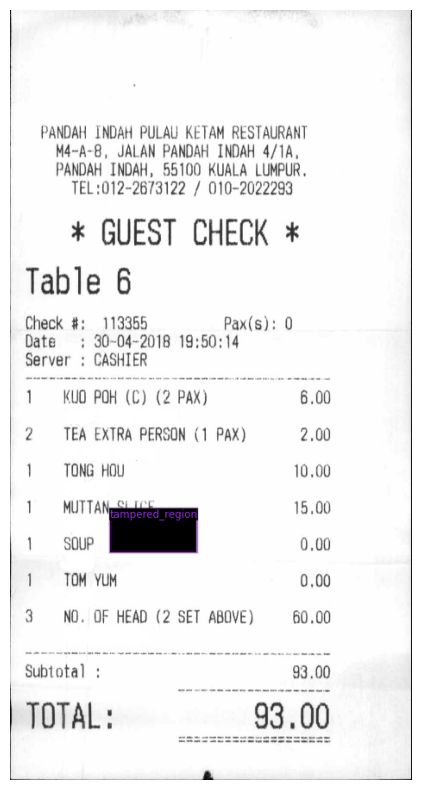

In [8]:
import random
from detectron2.utils.visualizer import Visualizer
import matplotlib.pyplot as plt

dataset_dicts = get_receipt_dicts(train_path)
d = random.sample(dataset_dicts, 1)[0]
img = cv2.imread(d["file_name"])
visualizer = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("receipt_train"), scale=0.5)
out = visualizer.draw_dataset_dict(d)

plt.figure(figsize=(10,10))
plt.imshow(out.get_image())
plt.axis('off')
plt.show()

In [9]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("receipt_train",)
cfg.DATASETS.TEST = () 

cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025 

cfg.SOLVER.MAX_ITER = 300 
cfg.SOLVER.STEPS = []       
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  

cfg.MODEL.DEVICE = "cpu"

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)

print("Configuration ready. Shall we begin training?")

C:\Users\JERMAGNE\forgery-detect\venv\Lib\site-packages\detectron2\model_zoo\model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


[04/30 14:01:40 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_280758.pkl: 167MB [00:06, 24.9MB/s]                                                                                                                            
C:\Users\JERMAGNE\forgery-detect\venv\Lib\site-packages\detectron2\checkpoint\detection_checkpoint.py:73: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")
Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the mo

Configuration ready. Shall we begin training?


In [10]:
trainer.train()

[04/30 14:05:48 d2.engine.train_loop]: Starting training from iteration 0


C:\Users\JERMAGNE\forgery-detect\venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0430 14:06:19.140000 288 Lib\site-packages\torch\fx\_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/30 14:22:45 d2.utils.events]:  eta: 3:59:00  iter: 19  total_loss: 0.8705  loss_cls: 0.5467  loss_box_reg: 0.2639  loss_rpn_cls: 0.02294  loss_rpn_loc: 0.001994    time: 50.5794  last_time: 51.4540  data_time: 0.6583  last_data_time: 0.0065   lr: 1.6068e-05  
[04/30 14:40:16 d2.utils.events]:  eta: 3:44:38  iter: 39  total_loss: 0.6812  loss_cls: 0.3664  loss_box_reg: 0.2582  loss_rpn_cls: 0.02458  loss_rpn_loc: 0.003982    time: 51.5815  last_time: 55.5057  data_time: 0.0063  last_data_time: 0.0057   lr: 3.2718e-05  
[04/30 14:56:48 d2.utils.events]:  eta: 3:26:17  iter: 59  total_loss: 0.6242  loss_cls: 0.2353  loss_box_reg: 0.3564  loss_rpn_cls: 0.003685  loss_rpn_loc: 0.002427    time: 50.8920  last_time: 52.1896  data_time: 0.0060  last_data_time: 0.0055   lr: 4.9367e-05  
[04/30 15:09:50 d2.utils.events]:  eta: 3:07:17  iter: 79  total_loss: 0.6116  loss_cls: 0.1912  loss_box_reg: 0.4078  loss_rpn_cls: 0.003465  loss_rpn_loc: 0.002078    time: 47.8690  last_time: 18.5638  dat

[04/30 16:43:28 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output\model_final.pth ...


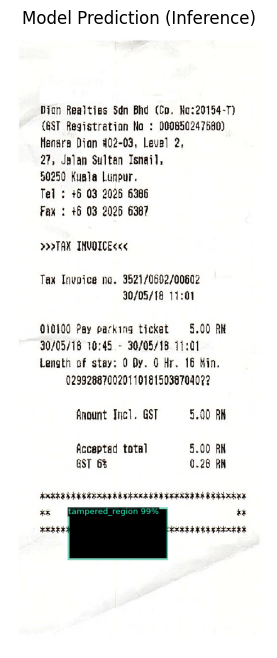

In [15]:
from detectron2.engine import DefaultPredictor

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  
predictor = DefaultPredictor(cfg)

d = random.sample(dataset_dicts, 1)[0]
im = cv2.imread(d["file_name"])

outputs = predictor(im)

v = Visualizer(im[:, :, ::-1],
               metadata=MetadataCatalog.get("receipt_train"), 
               scale=0.8)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(12, 8))
plt.imshow(out.get_image())
plt.title("Model Prediction (Inference)")
plt.axis('off')
plt.show()